In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('insurance.csv')

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Exploratory data analysis

In [6]:
data['age'].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

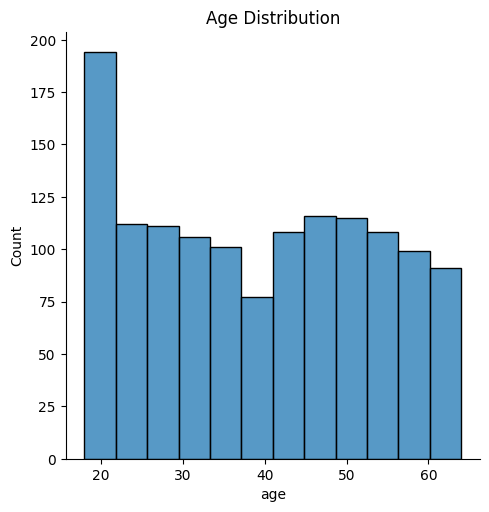

In [7]:
sns.displot(data['age'])
plt.title('Age Distribution')
plt.show()

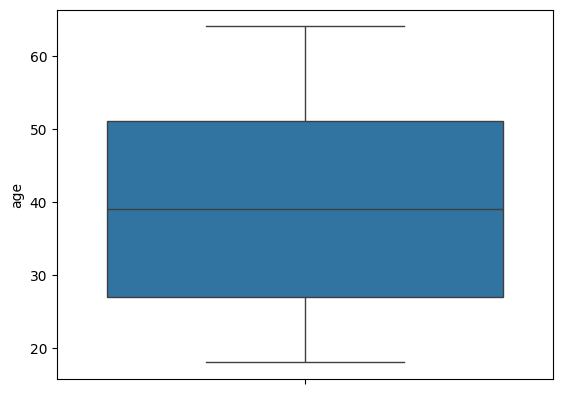

In [8]:
sns.boxplot(data=data['age'])
plt.show()

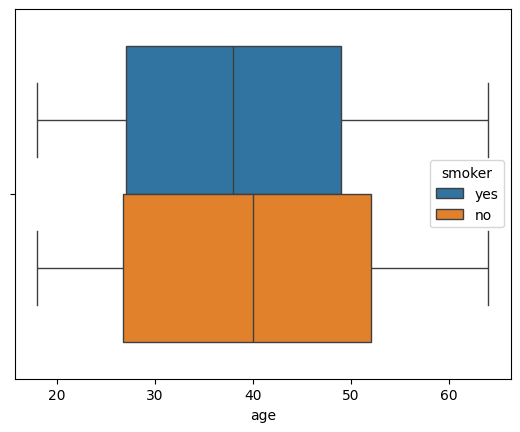

In [9]:
sns.boxplot(data=data, x='age',hue='smoker')
plt.show()

## BMI

In [10]:
data['bmi'].describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

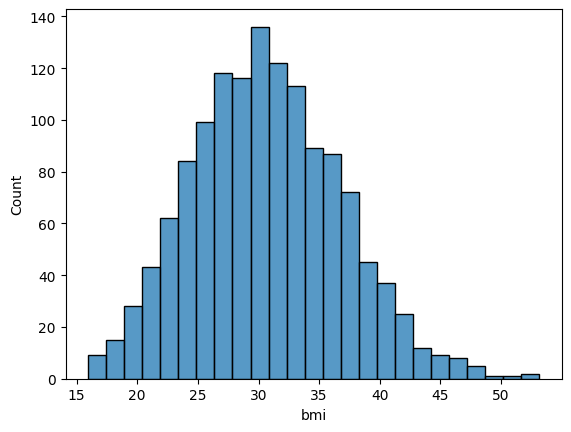

In [11]:
sns.histplot(data['bmi'])
plt.show()

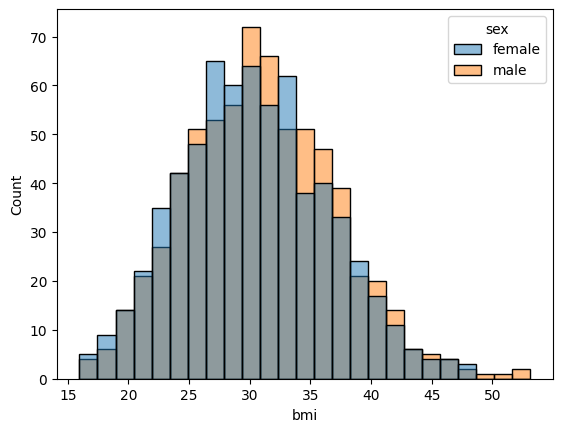

In [12]:
sns.histplot(data=data, x='bmi', hue='sex')
plt.show()

## Children

In [13]:
data['children'].describe()

count    1338.000000
mean        1.094918
std         1.205493
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

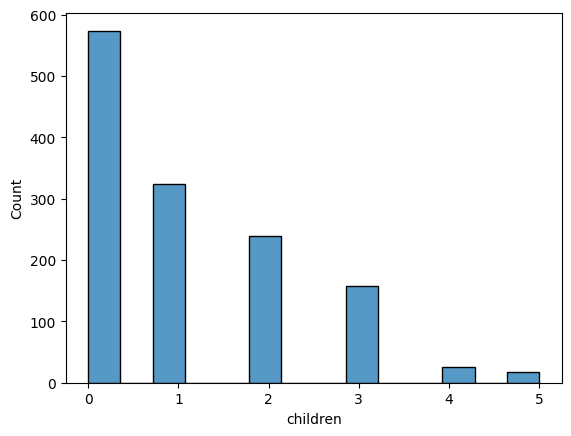

In [14]:
sns.histplot(data['children'])
plt.show()

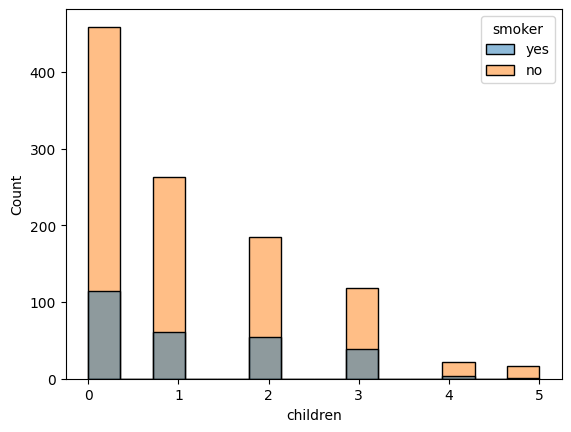

In [15]:
sns.histplot(data=data, x='children', hue='smoker')
plt.show()

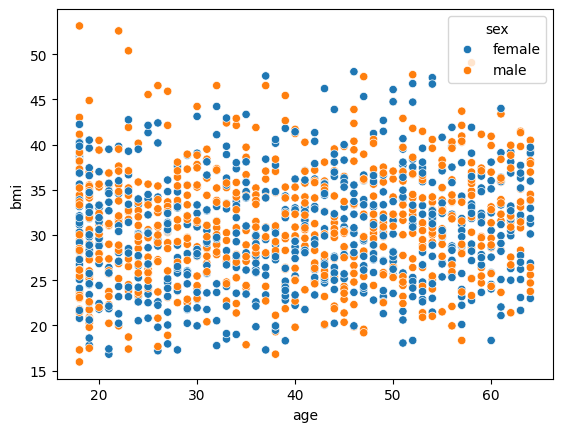

In [16]:
sns.scatterplot(data=data, x='age', y='bmi', hue='sex')
plt.show()

## sex

In [17]:
data['sex'].describe()

count     1338
unique       2
top       male
freq       676
Name: sex, dtype: object

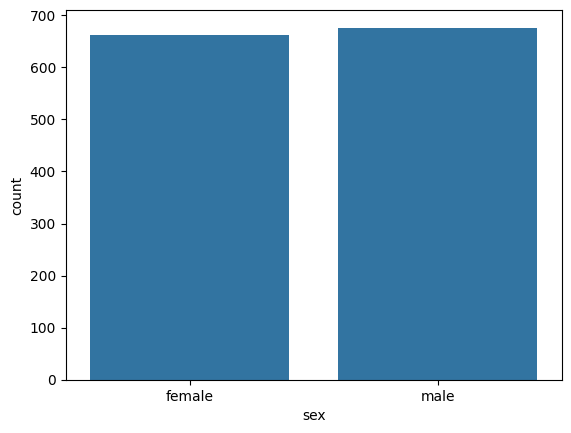

In [18]:
sns.countplot(data=data, x='sex')
plt.show()

### Children

In [19]:
data['children'].describe()

count    1338.000000
mean        1.094918
std         1.205493
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

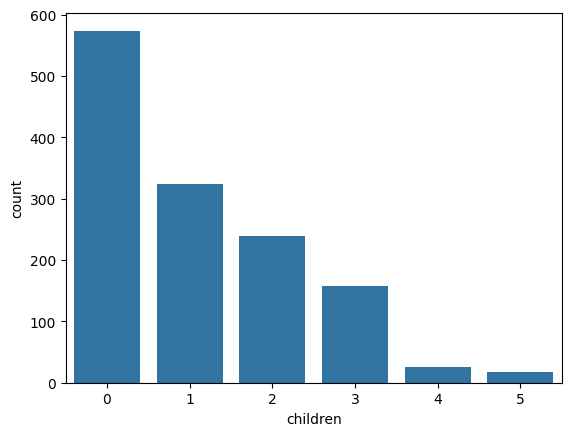

In [20]:
sns.countplot(data=data, x='children')
plt.show()

### Smoker

In [21]:
data['smoker'].describe()

count     1338
unique       2
top         no
freq      1064
Name: smoker, dtype: object

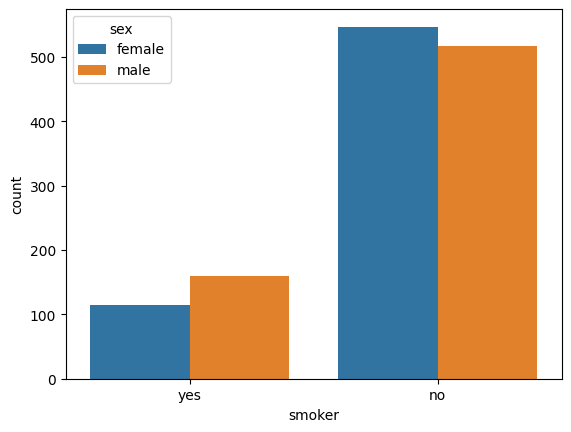

In [22]:
sns.countplot(data=data, x='smoker', hue='sex')
plt.show()

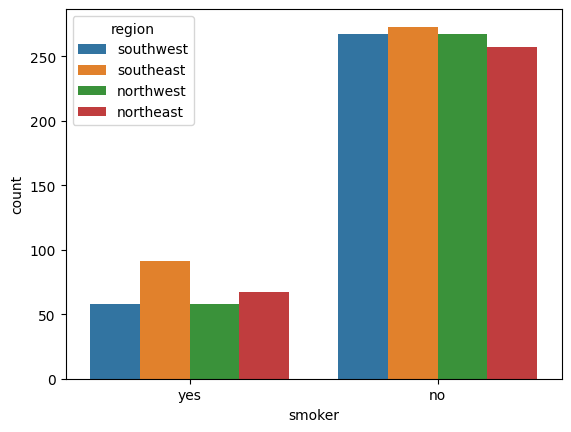

In [23]:
sns.countplot(data=data, x='smoker', hue='region')
plt.show()

### Region

In [24]:
data['region'].describe()

count          1338
unique            4
top       southeast
freq            364
Name: region, dtype: object

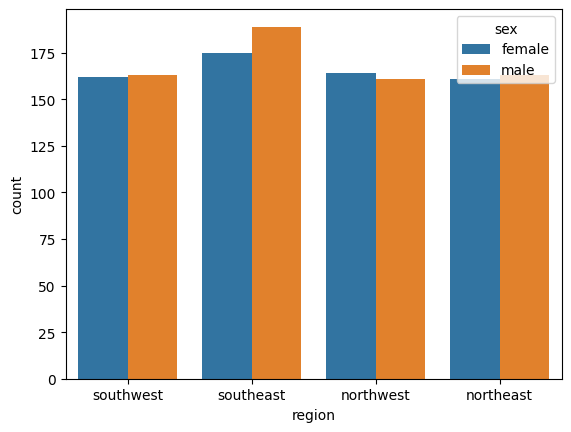

In [25]:
sns.countplot(data=data, x='region', hue='sex')
plt.show()

### Charges

In [26]:
data['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

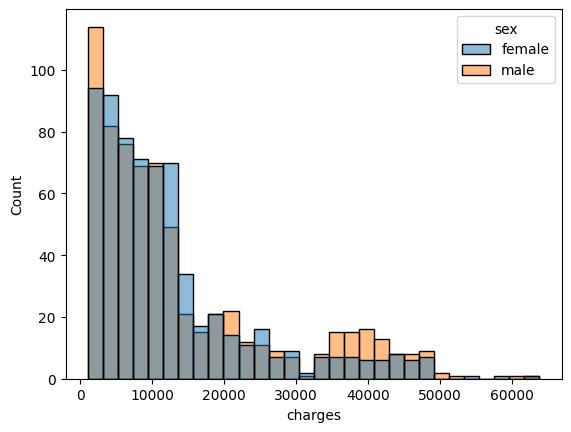

In [27]:
sns.histplot(data=data, x='charges', hue='sex')
plt.show()

In [28]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
categorical_columns = ['sex','smoker','region']

In [44]:
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(sparse_output=False, drop='first'),categorical_columns)],remainder='passthrough')

In [46]:
processed_data = preprocessor.fit_transform(data)

In [52]:
columns= preprocessor.get_feature_names_out()

In [53]:
df_processed = pd.DataFrame(processed_data, columns=columns)

In [54]:
df_processed

,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__charges
0,0.0,1.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...,...,...
1333,1.0,0.0,1.0,0.0,0.0,50.0,30.970,3.0,10600.54830
1334,0.0,0.0,0.0,0.0,0.0,18.0,31.920,0.0,2205.98080
1335,0.0,0.0,0.0,1.0,0.0,18.0,36.850,0.0,1629.83350
1336,0.0,0.0,0.0,0.0,1.0,21.0,25.800,0.0,2007.94500


<Axes: >

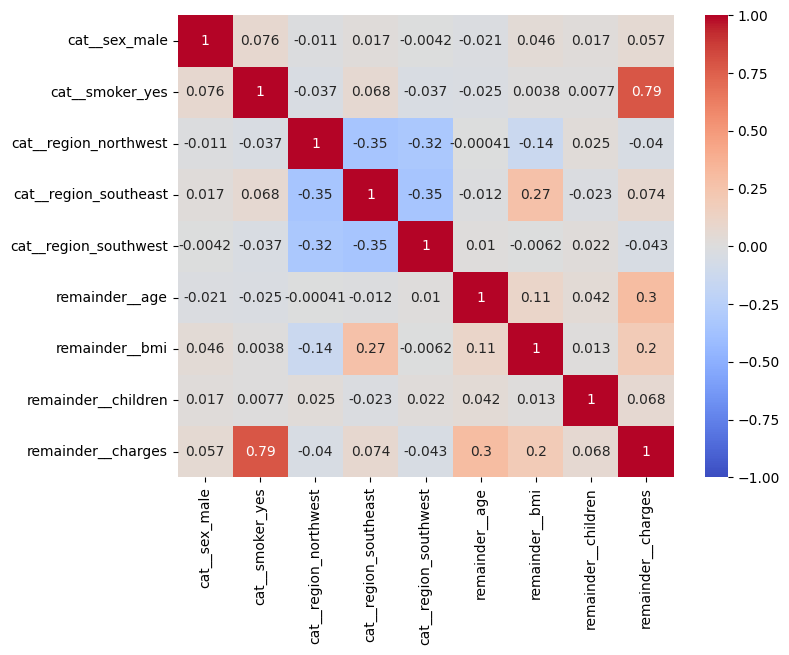

In [86]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_processed.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [57]:
X = df_processed.drop(['remainder__charges'],axis=1)

In [59]:
y = df_processed['remainder__charges']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=34)

In [76]:
regression = LinearRegression().fit(X_train,y_train)

In [82]:
regression.score(X_train,y_train)

0.7537297322473185

In [78]:
preds = regression.predict(X_test)

In [79]:
print("Coefficients: \n", regression.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, preds))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, preds))

Coefficients: 
 [ -520.80132442 24120.78053404   151.43315541 -1121.03614272
  -694.7067625    255.2718547    347.19517854   434.41612967]
Mean squared error: 36454308.61
Coefficient of determination: 0.74


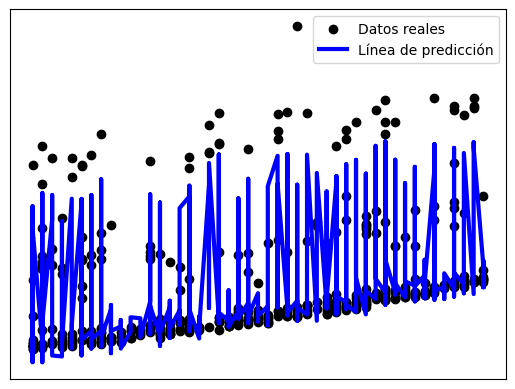

In [84]:
x_grafico = X_test['remainder__age'] 

# 2. Creamos un DataFrame temporal para ordenar X y las predicciones juntos
# Esto garantiza que mantengan el mismo tamaño y que la línea no se cruce rota
df_temporal = pd.DataFrame({
    'x': x_grafico,
    'preds': preds,
    'y_real': y_test
}).sort_values(by='x') # Los ordenamos por el eje X

# 3. Graficamos usando los datos perfectamente alineados y del mismo tamaño
plt.scatter(df_temporal['x'], df_temporal['y_real'], color="black", label="Datos reales")
plt.plot(df_temporal['x'], df_temporal['preds'], color="blue", linewidth=3, label="Línea de predicción")

# Tus configuraciones de limpieza de ejes
plt.xticks(())
plt.yticks(())

plt.legend()
plt.show()